# Project: Data Science Pipeline - Fashion Forward Forecasting

##### Data Scientist Nanodegree - Master of Science in Artificial Intelligence

##### Udacity - August 27, 2026

##### Alaa Alaboud - Dhahran - KSA

<BR>

<BR>

## Project Overview

"StyleSense", a rapidly growing online women's clothing retailer,  is known for its trendy and affordable fashion, and its customer base has exploded in recent months. 
This influx of new customers is fantastic for business, but it has created a challenge: a backlog of product reviews with missing data. Customers are still leaving valuable feedback in the text of their reviews, but they aren't always indicating whether they recommend the product.



## The target 

- **Recommended IND**: Binary variable stating where the customer recommends the product where `1` is recommended, `0` is not recommended.

## The features

##### The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.


## Data Loading & Library Imports

This section imports the required libraries, prepares the spaCy language model, loads the review dataset, and performs an initial inspection of the data.

In [1]:
# Import the libraries and tools needed for data processing and model building

import pandas as pd
import numpy as np
import spacy
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import ConfusionMatrixDisplay


##### Run this command once if the spaCy English model is not installed !

In [2]:
# !python -m spacy download en_core_web_sm

In [3]:
# The relative path matches the supplied Udacity starter structure.
df = pd.read_csv('data/reviews.csv')

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              18442 non-null  int64
 1   Age                      18442 non-null  int64
 2   Title                    18442 non-null  str  
 3   Review Text              18442 non-null  str  
 4   Positive Feedback Count  18442 non-null  int64
 5   Division Name            18442 non-null  str  
 6   Department Name          18442 non-null  str  
 7   Class Name               18442 non-null  str  
 8   Recommended IND          18442 non-null  int64
dtypes: int64(4), str(5)
memory usage: 1.3 MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Preparing features (`X`) & target (`y`)

This section separates the input features (X) from the target variable (y), then splits the data into training and test sets for model development and evaluation.

In [4]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [5]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

## Data Exploration

This section explores the training data, target distribution, and feature characteristics before building the preprocessing pipeline.

In [6]:
# Display summary statistics for the numerical training features

X_train.describe()

,Clothing ID,Age,Positive Feedback Count
count,16597.000000,16597.000000,16597.000000
mean,954.951618,43.370609,2.713924
std,141.863331,12.216240,6.014332
min,2.000000,18.000000,0.000000
25%,863.000000,34.000000,0.000000
50%,952.000000,42.000000,1.000000
75%,1078.000000,52.000000,3.000000
max,1205.000000,99.000000,122.000000


In [7]:
# Print and check the distribution of the target classes in the training data

print('\nTraining target counts:')
print(y_train.value_counts())

print('\nTraining target percentages:')
print((y_train.value_counts(normalize=True) * 100).round(2))

# Check for duplicate rows in the training features
print('Duplicate feature rows:', X_train.duplicated().sum())



Training target counts:
Recommended IND
1    13535
0     3062
Name: count, dtype: int64

Training target percentages:
Recommended IND
1    81.55
0    18.45
Name: proportion, dtype: float64
Duplicate feature rows: 0


### Insight 1:

The target is imbalanced: approximately **81.55%** of observations are class `1`, while **18.45%** are class `0`. Accuracy alone could therefore hide weak performance on customers who do not recommend a product.

In [8]:
# Explore categorical features

categorical_columns = [
    'Clothing ID',
    'Division Name',
    'Department Name',
    'Class Name'
]

for column in categorical_columns:
    print(f"\n{column}")
    print(f"Number of categories: {X_train[column].nunique()}")
    print(X_train[column].value_counts())


Clothing ID
Number of categories: 520
Clothing ID
1078    792
862     594
1094    590
1081    437
829     415
       ... 
603       1
1182      1
537       1
1183      1
1186      1
Name: count, Length: 520, dtype: int64

Division Name
Number of categories: 2
Division Name
General           10497
General Petite     6100
Name: count, dtype: int64

Department Name
Number of categories: 6
Department Name
Tops        7818
Dresses     4845
Bottoms     2852
Jackets      813
Intimate     172
Trend         97
Name: count, dtype: int64

Class Name
Number of categories: 14
Class Name
Dresses           4845
Knits             3554
Blouses           2337
Sweaters          1095
Pants             1041
Jeans              885
Fine gauge         832
Skirts             693
Jackets            549
Outerwear          264
Shorts             232
Lounge             172
Trend               97
Casual bottoms       1
Name: count, dtype: int64


In [9]:
# Explore numerical features
numerical_columns = [
    'Age',
    'Positive Feedback Count'
]

for column in numerical_columns:
    print(f"\n{column}")
    print(X_train[column].describe())


Age
count    16597.000000
mean        43.370609
std         12.216240
min         18.000000
25%         34.000000
50%         42.000000
75%         52.000000
max         99.000000
Name: Age, dtype: float64

Positive Feedback Count
count    16597.000000
mean         2.713924
std          6.014332
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max        122.000000
Name: Positive Feedback Count, dtype: float64


## Building the Preprocessing Pipeline

This section prepares numerical, categorical, and text features using separate preprocessing steps that are later combined into a single pipeline.

In [10]:
# Split features into numerical, categorical, and text features

num_features = (X
    .select_dtypes(exclude=['object']).columns
    .drop('Clothing ID'))

print('Numerical features:', num_features)

cat_features = (X[[
    'Clothing ID',
    'Division Name',
    'Department Name',
    'Class Name',
]].columns
               )
print('Categorical features:', cat_features)

text_features = (X[[
    'Title',
    'Review Text',
]].columns
                )
print ('Text features:', text_features)

Numerical features: Index(['Age', 'Positive Feedback Count'], dtype='str')
Categorical features: Index(['Clothing ID', 'Division Name', 'Department Name', 'Class Name'], dtype='str')
Text features: Index(['Title', 'Review Text'], dtype='str')


In [11]:
# Define pipeline for numerical features

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())
])
num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for 

In [12]:
# Define the preprocessing pipeline for categorical features
cat_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='most_frequent'),
    ),
    (
        'cat_encoder',
        OneHotEncoder(
            sparse_output=False,
            handle_unknown='ignore',
        ),
    ),
])

cat_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('cat_encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatort

## Preparing spaCy for Text Processing

This section prepares the spaCy English language model and demonstrates tokenization and lemmatization before integrating NLP into the pipeline.

In [13]:
# Load the pre-trained English spaCy language model
nlp = spacy.load('en_core_web_sm')

In [14]:
# Get the tokens using spaCy

review_text = X_train['Review Text'].iloc[0]
title = X_train['Title'].iloc[0]

review_tokens = nlp.tokenizer(review_text)
title_tokens = nlp.tokenizer(title)

In [15]:
# Display the tokens generated from the sample review
for token in review_tokens:
    print(token.text)

Easy
and
fun
jumper
.
runs
slightly
large
.
i
ordered
a
medium
and
returned
for
a
small
.
can
be
dressed
up
or
down
for
a
variety
of
occasions
.
would
be
perfect
if
it
had
pockets
.


In [16]:
# Display the tokens generated from the sample title
for token in title_tokens:
    print(token.text)

Super
cute
.
pockets
would
be
nice


In [17]:
diffs_review: list[tuple[str, str]] = []
# Use spaCy to compare the tokens before and after lemmatization

doc = nlp(review_text)

for token in doc:
    if token.text != token.lemma_:
        diffs_review.append((token.text, token.lemma_))

diffs_review

[('Easy', 'easy'),
 ('runs', 'run'),
 ('i', 'I'),
 ('ordered', 'order'),
 ('returned', 'return'),
 ('dressed', 'dress'),
 ('occasions', 'occasion'),
 ('had', 'have'),
 ('pockets', 'pocket')]

In [18]:
diffs_title: list[tuple[str, str]] = []
# Use spaCy to compare the tokens before and after lemmatization

doc = nlp(title)

for token in doc:
    if token.text != token.lemma_:
        diffs_title.append((token.text, token.lemma_))

diffs_title

[('Super', 'super'), ('pockets', 'pocket')]

In [19]:
# Define a custom transformer to count adjectives using spaCy POS tags
class AdjectiveCounter(BaseEstimator, TransformerMixin):
    def __init__(self, nlp):
        self.nlp = nlp

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        adjective_counts = []

        for doc in self.nlp.pipe(X):
            count = sum(1 for token in doc if token.pos_ == 'ADJ')
            adjective_counts.append([count])

        return np.array(adjective_counts)

## Text Preprocessing and Feature Engineering

This section preprocesses numerical, categorical, and text features, applies spaCy-based text lemmatization and TF-IDF vectorization, and combines all preprocessing steps into a unified ColumnTransformer for model training.

In [20]:
# Define a custom spaCy transformer for text lemmatization and cleaning

class SpacyLemmatizer(BaseEstimator, TransformerMixin):
    def __init__(self, nlp):
        self.nlp = nlp

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        lemmatized_text = []

        for doc in self.nlp.pipe(X):
            lemmas = [
                token.lemma_ 
                for token in doc 
                if not token.is_stop
                and not token.is_punct
                and not token.is_space
            ]
            lemmatized_text.append(' '.join(lemmas))

        return lemmatized_text

In [21]:
# Build the text pipeline: lemmatize text, then convert it to TF-IDF features

text_pipeline = Pipeline([
    (
        'lemmatizer',
        SpacyLemmatizer(nlp=nlp)
    ),
    (
        'tfidf',
        TfidfVectorizer()
    ),
])

text_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('lemmatizer', ...), ('tfidf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,nlp,<spacy.lang.e...t 0x11c09d6a0>
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None


In [22]:
# Combine preprocessing pipelines for numerical, categorical, and text features

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
    ('title', text_pipeline, 'Title'),
    ('review', text_pipeline, 'Review Text'),
    ('review_adj_count', AdjectiveCounter(nlp), 'Review Text')
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

## Model `1` Training Pipeline

This section builds and evaluates the first machine learning pipeline using Logistic Regression.

### Baseline Logistic Regression

This section trains and evaluates the baseline Logistic Regression model using the complete preprocessing pipeline.

In [23]:
# Build the baseline classification pipeline using the shared preprocessor

logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=27
    ))
])

In [24]:
# Train the baseline Logistic Regression pipeline on the training data

logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Clothing ID','Age','Title',...,'Division Name','Department Name', 'Class Name']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [25]:
# Generate predictions on the test data using the baseline Logistic Regression model

y_pred_logistic = logistic_pipeline.predict(X_test)

In [26]:
# Evaluate the baseline model using classification metrics and the confusion matrix

print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall:", recall_score(y_test, y_pred_logistic))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Accuracy: 0.8807588075880759
Precision: 0.9662356321839081
Recall: 0.886034255599473

Confusion Matrix:
[[ 280   47]
 [ 173 1345]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.86      0.72       327
           1       0.97      0.89      0.92      1518

    accuracy                           0.88      1845
   macro avg       0.79      0.87      0.82      1845
weighted avg       0.90      0.88      0.89      1845



### Insight 2:

The classifiers use balanced class weights, Logistic Regression tuning uses macro F1, and the final evaluation reports per-class precision, recall, F1-score, and a confusion matrix.

## Fine-Tuning Logistic Regression

This section uses RandomizedSearchCV to search for improved Logistic Regression hyperparameters using macro F1-score.

In [27]:
# Define the hyperparameter search space and configure RandomizedSearchCV

param_distributions_logistic = {
    'classifier__C': [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    'classifier__class_weight': ['balanced'],
    'classifier__solver': ['liblinear', 'lbfgs']
}

logistic_search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=param_distributions_logistic,
    n_iter=14,
    scoring='f1_macro',
    cv=3,
    random_state=27,
    n_jobs=-1,
    verbose=1
)

In [28]:
# Run the hyperparameter search on the training data

logistic_search.fit(X_train, y_train)

Fitting 3 folds for each of 14 candidates, totalling 42 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=27))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__C': [0.2, 0.3, ...], 'classifier__class_weight': ['balanced'], 'classifier__solver': ['liblinear', 'lbfgs']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",14
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",27
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the

In [29]:
# Display the best hyperparameters and cross-validation score

print("Best parameters:", logistic_search.best_params_)
print("Best CV score:", logistic_search.best_score_)

Best parameters: {'classifier__solver': 'liblinear', 'classifier__class_weight': 'balanced', 'classifier__C': 0.8}
Best CV score: 0.8286117216153549


In [30]:
# Select the best tuned model and generate predictions on the test data

best_logistic = logistic_search.best_estimator_
y_pred_logistic_final = best_logistic.predict(X_test)

In [31]:
# Evaluate the tuned Logistic Regression model on the test data

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_logistic_final)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_logistic_final)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_logistic_final)
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic_final))

Accuracy: 0.8791327913279133
Precision: 0.9661627069834413
Recall: 0.8840579710144928

Confusion Matrix:
[[ 280   47]
 [ 176 1342]]

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.86      0.72       327
           1       0.97      0.88      0.92      1518

    accuracy                           0.88      1845
   macro avg       0.79      0.87      0.82      1845
weighted avg       0.90      0.88      0.89      1845



### Insight 3:

The tuned Logistic Regression achieved a macro F1-score of **0.82** on the test set. Performance remained strong for the majority class while maintaining substantially higher recall (**0.86**) than precision (**0.61**) for the minority class, showing that the model captures most non-recommendations despite some false positives.

## Model `2` Training Pipeline

This section builds and evaluates the second machine learning pipeline using Random Forest as an alternative classifier.

## Random Forest Experiment

This section evaluates Random Forest as an alternative classification model using the same preprocessing pipeline.

In [32]:
# Build a Random Forest pipeline using the same shared preprocessor

random_forest_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    (
        'classifier',
        RandomForestClassifier(
            class_weight='balanced',
            random_state=27
        )
    )
])

random_forest_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default

In [33]:
# Train the baseline Random Forest pipeline on the training data

random_forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Clothing ID','Age','Title',...,'Division Name','Department Name', 'Class Name']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [34]:
# Generate predictions on the test data using the baseline Random Forest model

y_pred_rf = random_forest_pipeline.predict(X_test)

In [35]:
# Evaluate the baseline Random Forest model on the test data

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.884010840108401
Precision: 0.9179487179487179
Recall: 0.9433465085638999

Confusion Matrix:
[[ 199  128]
 [  86 1432]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.61      0.65       327
           1       0.92      0.94      0.93      1518

    accuracy                           0.88      1845
   macro avg       0.81      0.78      0.79      1845
weighted avg       0.88      0.88      0.88      1845



### Insight 4:

The baseline Random Forest achieved approximately **88.40%** accuracy and a macro F1-score of **0.79**. While it performed strongly on class `1` with an F1-score of **0.93**, its performance on class `0` was weaker, with an F1-score of **0.65**. This indicates that the model is better at identifying customers who recommend a product than those who do not.

## Fine-Tuning Random Forest

This section uses RandomizedSearchCV to search for improved Random Forest hyperparameters using macro F1-score.

In [36]:
# Define the hyperparameter search space and configure RandomizedSearchCV

param_distributions_rf = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__class_weight': ['balanced']
}

random_forest_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=param_distributions_rf,
    n_iter=10,
    scoring='f1_macro',
    cv=3,
    random_state=27,
    n_jobs=-1,
    verbose=1
)

In [37]:
# Run the hyperparameter search on the training data
random_forest_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=27))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__class_weight': ['balanced'], 'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",27
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best esti

In [38]:
# Display the best hyperparameters and cross-validation score

print("Best parameters:", random_forest_search.best_params_)
print("Best CV score:", random_forest_search.best_score_)

Best parameters: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': None, 'classifier__class_weight': 'balanced'}
Best CV score: 0.8175650552980915


In [39]:
# Select the best tuned Random Forest model and generate predictions

best_random_forest = random_forest_search.best_estimator_
y_pred_rf_final = best_random_forest.predict(X_test)

In [40]:
# Evaluate the tuned Random Forest model on the test data

print("Accuracy:", accuracy_score(y_test, y_pred_rf_final))
print("Precision:", precision_score(y_test, y_pred_rf_final))
print("Recall:", recall_score(y_test, y_pred_rf_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_final))

Accuracy: 0.8785907859078591
Precision: 0.9443681318681318
Recall: 0.9057971014492754

Confusion Matrix:
[[ 246   81]
 [ 143 1375]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.75      0.69       327
           1       0.94      0.91      0.92      1518

    accuracy                           0.88      1845
   macro avg       0.79      0.83      0.81      1845
weighted avg       0.89      0.88      0.88      1845



### Insight 5:

Fine-tuning improved the Random Forest model's performance on the minority class. The recall for class `0` increased from **0.61** to **0.75**, while its F1-score improved from **0.65** to **0.69**. Although overall accuracy decreased slightly from **88.40%** to **87.86%**, the tuned model achieved a better balance between the two classes, with a macro F1-score of **0.81**.

## Model Comparison

This section compares the trained models using accuracy, macro F1-score, and weighted F1-score to select the final model.

| Model | Accuracy | Macro F1 | Weighted F1 |
|---|---:|---:|---:|
| Baseline Logistic Regression | 0.881 | 0.821 | 0.888 |
| Tuned Logistic Regression | 0.879 | 0.819 | 0.886 |
| Baseline Random Forest | 0.884 | 0.790 | 0.881 |
| Tuned Random Forest | 0.879 | 0.806 | 0.883 |

### Insight 6:

Although the baseline Random Forest achieved the highest overall accuracy, the baseline Logistic Regression achieved the highest macro F1-score **(0.821)** and showed more balanced performance across both classes. Since the target is imbalanced, the baseline Logistic Regression was selected as the final model.

## Final Model Evaluation

This section evaluates the selected final model on the test data using classification metrics and a confusion matrix.

### Baseline Logistic Regression

The **Baseline Logistic Regression** model was selected as the final model because it achieved the highest Macro F1-score and provided the best balance between the two target classes.

In [41]:
# Use the selected baseline Logistic Regression as the final model
final_model = logistic_pipeline

# Generate final predictions on the test data
y_pred_final = final_model.predict(X_test)

# Evaluate the final model
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

Accuracy: 0.8807588075880759
Precision: 0.9662356321839081
Recall: 0.886034255599473

Confusion Matrix:
[[ 280   47]
 [ 173 1345]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.86      0.72       327
           1       0.97      0.89      0.92      1518

    accuracy                           0.88      1845
   macro avg       0.79      0.87      0.82      1845
weighted avg       0.90      0.88      0.89      1845



### Insight 7:

The selected final model achieved approximately **88.08%** accuracy and a macro F1-score of **0.82**. It achieved **0.86** recall for class `0` and **0.89** recall for class `1`, showing relatively balanced performance despite the class imbalance.

## Final Model Visualization

This section visualizes the final model's classification performance using a confusion matrix.

### Confusion Matrix

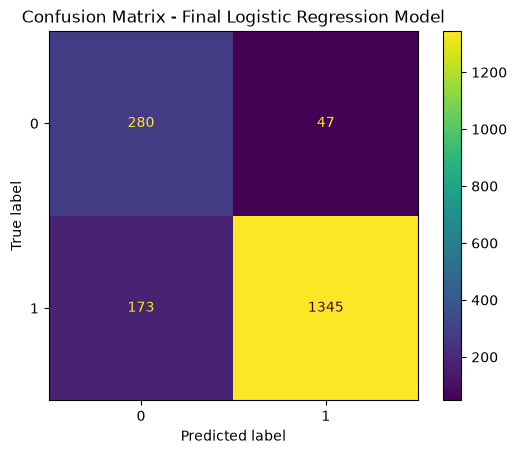

In [45]:
# Visualize the confusion matrix for the final model

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final
)

plt.title("Confusion Matrix - Final Logistic Regression Model")

plt.savefig(
    "images/final_model_result.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

### Insight 8:

The confusion matrix shows that the final Logistic Regression model correctly classified **280 of 327** class `0` observations and **1,345 of 1,518** class `1` observations. This confirms that the model maintains relatively balanced performance across both classes despite the target imbalance.

## Conclusion

The final pipeline combines numerical preprocessing, categorical encoding, spaCy lemmatization, TF-IDF feature extraction, and Logistic Regression for predicting whether a customer recommends a product.

After comparing Logistic Regression and Random Forest models, the baseline Logistic Regression was selected as the final model because it achieved the highest macro F1-score and showed more balanced performance across both classes.

The final model achieved approximately **88.08%** accuracy and a macro F1-score of **0.82**, with recall scores of **0.86** for class `0` and **0.89** for class `1`. These results show that the pipeline can effectively use both structured data and customer review text to predict product recommendations.